In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Rows:", len(df))
print("Start:", df["Date"].min())
print("End:", df["Date"].max())

Rows: 1170
Start: 2023-01-12 00:00:00
End: 2025-12-21 00:00:00


In [3]:
cols = [
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [4]:
df["Total System Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

df = df.sort_values("Date").reset_index(drop=True)

df[["Date", "Total System Load"]].head()

,Date,Total System Load
0,2023-01-12,NaN
1,2023-01-22,NaN
2,2023-01-23,NaN
3,2023-01-24,NaN
4,2023-01-25,NaN


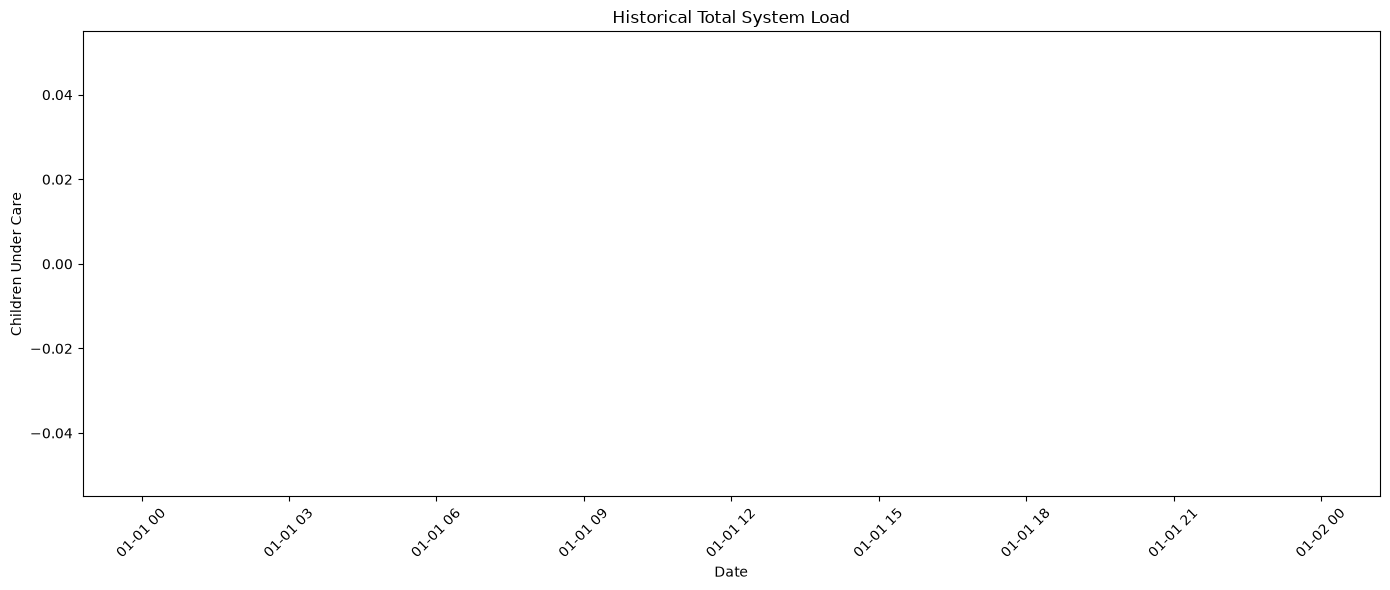

In [5]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Total System Load"],
    linewidth=2
)

plt.title("Historical Total System Load")
plt.xlabel("Date")
plt.ylabel("Children Under Care")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
forecast_days = 30

recent_average = (
    df["Total System Load"]
    .tail(30)
    .mean()
)

print("Recent 30-Day Average Load:", round(recent_average, 2))

Recent 30-Day Average Load: nan


In [7]:
last_date = df["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted System Load": recent_average
})

forecast_df.head()

,Date,Forecasted System Load
0,2025-12-22,NaN
1,2025-12-23,NaN
2,2025-12-24,NaN
3,2025-12-25,NaN
4,2025-12-26,NaN


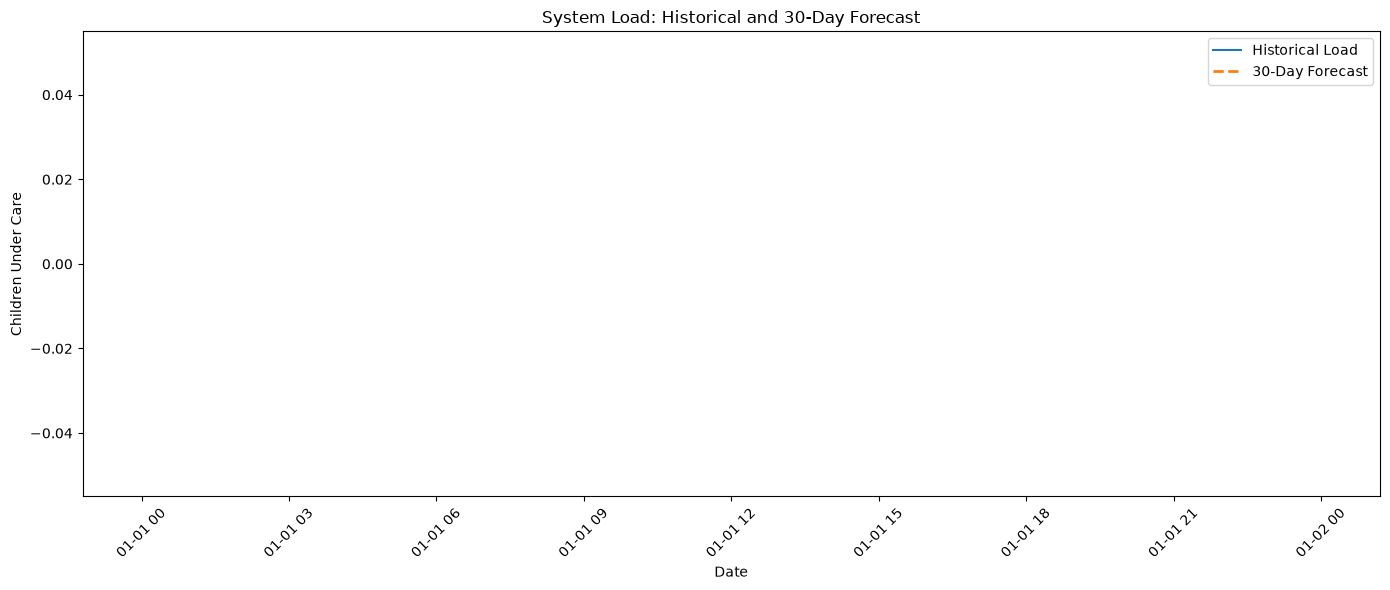

In [8]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Total System Load"],
    label="Historical Load"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted System Load"],
    linestyle="--",
    linewidth=2,
    label="30-Day Forecast"
)

plt.title("System Load: Historical and 30-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Children Under Care")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
forecast_df.to_csv(
    "../data/processed/30_day_forecast.csv",
    index=False
)

print("✅ 30-day forecast saved successfully!")

✅ 30-day forecast saved successfully!


In [11]:
import statsmodels
print("Statsmodels:", statsmodels.__version__)

Statsmodels: 0.14.6


In [12]:
monthly_df = (
    df.set_index("Date")["Total System Load"]
      .resample("MS")
      .mean()
      .dropna()
)

monthly_df.head()

Series([], Name: Total System Load, dtype: float64)

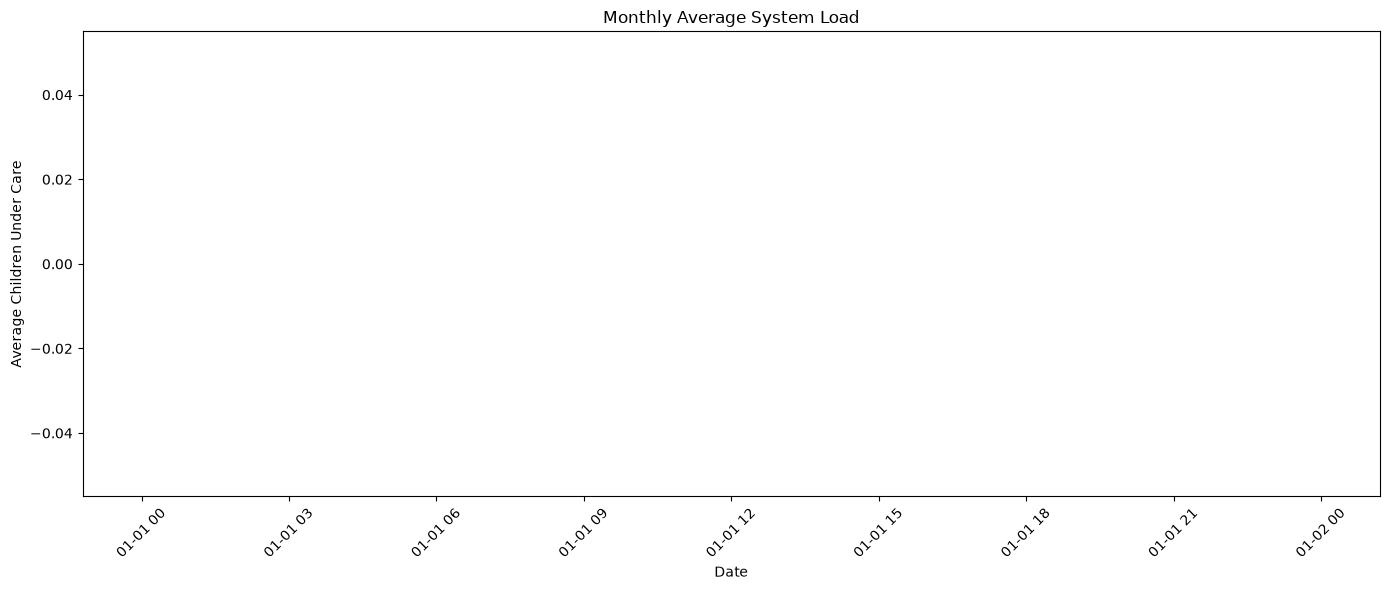

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(monthly_df.index, monthly_df.values, linewidth=2)

plt.title("Monthly Average System Load")
plt.xlabel("Date")
plt.ylabel("Average Children Under Care")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
from statsmodels.tsa.arima.model import ARIMA

In [15]:
model = ARIMA(
    monthly_df,
    order=(1, 1, 1)
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      Total System Load   No. Observations:                    0
Model:                 ARIMA(1, 1, 1)   Log Likelihood                   0.000
Date:                Sat, 08 Aug 2026   AIC                              6.000
Time:                        16:49:05   BIC                                nan
Sample:                             0   HQIC                               nan
                                  - 0                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1               0         -0        nan        nan           0           0
ma.L1               0         -0        nan        nan           0           0
sigma2         1.0000         -0       -inf      0.0

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to es

In [16]:
forecast_steps = 6

forecast = model_fit.forecast(
    steps=forecast_steps
)

forecast

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
Name: predicted_mean, dtype: float64

In [17]:
future_dates = pd.date_range(
    start=monthly_df.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq="MS"
)

arima_forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecasted System Load": forecast.values
})

arima_forecast

IndexError: index -1 is out of bounds for axis 0 with size 0

In [18]:
monthly_df.index[-1]

IndexError: index -1 is out of bounds for axis 0 with size 0

In [19]:
print("Total rows:", len(df))
print("\nDate information:")
print(df["Date"].head())
print(df["Date"].tail())
print("\nDate dtype:", df["Date"].dtype)

print("\nSystem Load:")
print(df["Total System Load"].head())
print(df["Total System Load"].tail())
print("\nSystem Load dtype:", df["Total System Load"].dtype)

Total rows: 1170

Date information:
0   2023-01-12
1   2023-01-22
2   2023-01-23
3   2023-01-24
4   2023-01-25
Name: Date, dtype: datetime64[us]
1165   NaT
1166   NaT
1167   NaT
1168   NaT
1169   NaT
Name: Date, dtype: datetime64[us]

Date dtype: datetime64[us]

System Load:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Total System Load, dtype: float64
1165   NaN
1166   NaN
1167   NaN
1168   NaN
1169   NaN
Name: Total System Load, dtype: float64

System Load dtype: float64


In [20]:
print("Valid Dates:", df["Date"].notna().sum())
print("Valid System Load:", df["Total System Load"].notna().sum())

Valid Dates: 720
Valid System Load: 0


In [21]:
df = df.copy()

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Total System Load"] = pd.to_numeric(
    df["Total System Load"],
    errors="coerce"
)

df = df.dropna(subset=["Date", "Total System Load"])
df = df.sort_values("Date")

monthly_df = (
    df.set_index("Date")["Total System Load"]
      .resample("MS")
      .mean()
      .dropna()
)

print("Monthly rows:", len(monthly_df))
print(monthly_df)

Monthly rows: 0
Series([], Freq: MS, Name: Total System Load, dtype: float64)


In [22]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    monthly_df,
    order=(1, 1, 1)
)

model_fit = model.fit()

print(model_fit.summary())

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:534: RuntimeWarning: invalid value encountered in scalar divide
  return -self.loglike(params, *args) / nobs
c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


IndexError: index 0 is out of bounds for axis 0 with size 0

In [23]:
print("Number of monthly observations:", len(monthly_df))
print("\nMonthly data:")
print(monthly_df)

Number of monthly observations: 0

Monthly data:
Series([], Freq: MS, Name: Total System Load, dtype: float64)


In [24]:
print("Missing values:", monthly_df.isna().sum())
print("Infinite values:", np.isinf(monthly_df).sum())
print("Unique values:", monthly_df.nunique())

Missing values: 0
Infinite values: 0
Unique values: 0


In [25]:
monthly_df = monthly_df.replace([np.inf, -np.inf], np.nan).dropna()

monthly_df = monthly_df.astype(float)

print("Clean observations:", len(monthly_df))
print(monthly_df)

Clean observations: 0
Series([], Freq: MS, Name: Total System Load, dtype: float64)


In [26]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    monthly_df,
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()

print(model_fit.summary())

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:534: RuntimeWarning: invalid value encountered in scalar divide
  return -self.loglike(params, *args) / nobs
c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


IndexError: index 0 is out of bounds for axis 0 with size 0

In [27]:
# Baseline 30-Day Forecast

forecast_days = 30

recent_average = (
    df["Total System Load"]
    .tail(30)
    .mean()
)

last_date = df["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted System Load": recent_average
})

forecast_df.head()

ValueError: Neither `start` nor `end` can be NaT

In [28]:
print(df["Date"].head(10))
print("\nData type:", df["Date"].dtype)
print("\nValid dates:", df["Date"].notna().sum())
print("Invalid dates:", df["Date"].isna().sum())

Series([], Name: Date, dtype: datetime64[us])

Data type: datetime64[us]

Valid dates: 0
Invalid dates: 0


In [29]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df = df.dropna(subset=["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print("Valid dates:", df["Date"].notna().sum())
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

Valid dates: 0
First date: NaT
Last date: NaT


In [30]:
df["Total System Load"] = (
    pd.to_numeric(df["Children in CBP custody"], errors="coerce")
    +
    pd.to_numeric(df["Children in HHS Care"], errors="coerce")
)

df = df.dropna(subset=["Total System Load"])

print("Rows available:", len(df))
print(df[["Date", "Total System Load"]].tail())

Rows available: 0
Empty DataFrame
Columns: [Date, Total System Load]
Index: []


In [31]:
forecast_days = 30

recent_average = df["Total System Load"].tail(30).mean()

last_date = df["Date"].max()

print("Last Date:", last_date)
print("Recent Average:", round(recent_average, 2))

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted System Load": recent_average
})

forecast_df.head()

Last Date: NaT
Recent Average: nan


ValueError: Neither `start` nor `end` can be NaT

In [32]:
print(df["Date"].head(20).to_string())
print("\nOriginal dtype:", df["Date"].dtype)


Series([], )

Original dtype: datetime64[us]


In [33]:
df["Date"] = df["Date"].astype(str).str.strip()

print(df["Date"].head(20).to_string())

Series([], )


In [34]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce",
    format="mixed"
)

print("Valid dates:", df["Date"].notna().sum())
print("Invalid dates:", df["Date"].isna().sum())
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

Valid dates: 0
Invalid dates: 0
First date: NaT
Last date: NaT


In [35]:
print(df["Date"].head(20).to_list())

[]


In [36]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv"
)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

Rows: 1170
Columns: ['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']


In [37]:
print(df["Date"].head(20).to_list())
print("Date dtype:", df["Date"].dtype)

['December 21, 2025', 'December 18, 2025', 'December 17, 2025', 'December 16, 2025', 'December 15, 2025', 'December 14, 2025', 'December 11, 2025', 'December 10, 2025', 'December 09, 2025', 'December 08, 2025', 'December 07, 2025', 'December 04, 2025', 'December 03, 2025', 'December 02, 2025', 'December 01, 2025', 'November 30, 2025', 'November 27, 2025', 'November 25, 2025', 'November 24, 2025', 'November 23, 2025']
Date dtype: str


In [38]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce",
    format="mixed"
)

print("Valid dates:", df["Date"].notna().sum())
print("Invalid dates:", df["Date"].isna().sum())
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

Valid dates: 720
Invalid dates: 450
First date: 2023-01-12 00:00:00
Last date: 2025-12-21 00:00:00


In [39]:
invalid_dates = df.loc[df["Date"].isna()]

print("Invalid date rows:", len(invalid_dates))
print(invalid_dates.head(20))

Invalid date rows: 450
    Date  Children apprehended and placed in CBP custody*  \
720  NaT                                              NaN   
721  NaT                                              NaN   
722  NaT                                              NaN   
723  NaT                                              NaN   
724  NaT                                              NaN   
725  NaT                                              NaN   
726  NaT                                              NaN   
727  NaT                                              NaN   
728  NaT                                              NaN   
729  NaT                                              NaN   
730  NaT                                              NaN   
731  NaT                                              NaN   
732  NaT                                              NaN   
733  NaT                                              NaN   
734  NaT                                              NaN   
7

In [40]:
raw_df = pd.read_csv(
    "../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv"
)

print(raw_df["Date"].head(30).to_list())

['December 21, 2025', 'December 18, 2025', 'December 17, 2025', 'December 16, 2025', 'December 15, 2025', 'December 14, 2025', 'December 11, 2025', 'December 10, 2025', 'December 09, 2025', 'December 08, 2025', 'December 07, 2025', 'December 04, 2025', 'December 03, 2025', 'December 02, 2025', 'December 01, 2025', 'November 30, 2025', 'November 27, 2025', 'November 25, 2025', 'November 24, 2025', 'November 23, 2025', 'November 20, 2025', 'November 19, 2025', 'November 18, 2025', 'November 17, 2025', 'November 16, 2025', 'November 13, 2025', 'November 12, 2025', 'November 11, 2025', 'November 09, 2025', 'November 06, 2025']


In [41]:
print(
    raw_df["Date"]
    .astype(str)
    .str.strip()
    .head(100)
    .to_list()
)

['December 21, 2025', 'December 18, 2025', 'December 17, 2025', 'December 16, 2025', 'December 15, 2025', 'December 14, 2025', 'December 11, 2025', 'December 10, 2025', 'December 09, 2025', 'December 08, 2025', 'December 07, 2025', 'December 04, 2025', 'December 03, 2025', 'December 02, 2025', 'December 01, 2025', 'November 30, 2025', 'November 27, 2025', 'November 25, 2025', 'November 24, 2025', 'November 23, 2025', 'November 20, 2025', 'November 19, 2025', 'November 18, 2025', 'November 17, 2025', 'November 16, 2025', 'November 13, 2025', 'November 12, 2025', 'November 11, 2025', 'November 09, 2025', 'November 06, 2025', 'November 05, 2025', 'November 04, 2025', 'November 03, 2025', 'November 02, 2025', 'October 30, 2025', 'October 29, 2025', 'October 28, 2025', 'October 27, 2025', 'October 26, 2025', 'October 23, 2025', 'October 22, 2025', 'October 21, 2025', 'October 20, 2025', 'October 19, 2025', 'October 16, 2025', 'October 15, 2025', 'October 14, 2025', 'October 13, 2025', 'Octo

In [42]:
df = pd.read_csv(
    "../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv"
)

df["Date"] = pd.to_datetime(
    df["Date"].astype(str).str.strip(),
    format="%B %d, %Y",
    errors="coerce"
)

print("Valid dates:", df["Date"].notna().sum())
print("Invalid dates:", df["Date"].isna().sum())
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

Valid dates: 720
Invalid dates: 450
First date: 2023-01-12 00:00:00
Last date: 2025-12-21 00:00:00


In [43]:
invalid = df[df["Date"].isna()]

print("Invalid rows:", len(invalid))

Invalid rows: 450


In [44]:
df = df.sort_values("Date").reset_index(drop=True)

print(df[["Date"]].head())
print(df[["Date"]].tail())

        Date
0 2023-01-12
1 2023-01-22
2 2023-01-23
3 2023-01-24
4 2023-01-25
     Date
1165  NaT
1166  NaT
1167  NaT
1168  NaT
1169  NaT


In [45]:
df["Children in CBP custody"] = pd.to_numeric(
    df["Children in CBP custody"],
    errors="coerce"
)

df["Children in HHS Care"] = pd.to_numeric(
    df["Children in HHS Care"],
    errors="coerce"
)

df["Total System Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

print(
    df[[
        "Date",
        "Children in CBP custody",
        "Children in HHS Care",
        "Total System Load"
    ]].head()
)

        Date  Children in CBP custody  Children in HHS Care  Total System Load
0 2023-01-12                     53.0                   NaN                NaN
1 2023-01-22                     49.0                   NaN                NaN
2 2023-01-23                     50.0                   NaN                NaN
3 2023-01-24                     42.0                   NaN                NaN
4 2023-01-25                     22.0                   NaN                NaN


In [46]:
last_date = df["Date"].max()

print("Last Date:", last_date)

Last Date: 2025-12-21 00:00:00


In [47]:
forecast_days = 30

recent_average = (
    df["Total System Load"]
    .tail(30)
    .mean()
)

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted System Load": recent_average
})

forecast_df.head()

,Date,Forecasted System Load
0,2025-12-22,NaN
1,2025-12-23,NaN
2,2025-12-24,NaN
3,2025-12-25,NaN
4,2025-12-26,NaN


In [48]:
df = pd.read_csv(
    "../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv"
)

df["Date"] = pd.to_datetime(
    df["Date"].astype(str).str.strip(),
    format="%B %d, %Y",
    errors="coerce"
)

print("Valid dates:", df["Date"].notna().sum())
print("Invalid dates:", df["Date"].isna().sum())
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

Valid dates: 720
Invalid dates: 450
First date: 2023-01-12 00:00:00
Last date: 2025-12-21 00:00:00


In [49]:
raw_df = pd.read_csv(
    "../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv"
)

raw_dates = raw_df["Date"].astype(str).str.strip()

print("Total rows:", len(raw_dates))

Total rows: 1170


In [50]:
test_dates = pd.to_datetime(
    raw_dates,
    format="%B %d, %Y",
    errors="coerce"
)

invalid_values = raw_dates[test_dates.isna()].unique()

print("Invalid unique values:", len(invalid_values))
print(invalid_values[:100])

Invalid unique values: 1
<ArrowStringArray>
[nan]
Length: 1, dtype: str


In [51]:
df = pd.read_csv(
    "../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv"
)

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%B %d, %Y",
    errors="coerce"
)

# Remove rows where Date is missing
df = df.dropna(subset=["Date"])

# Sort chronologically
df = df.sort_values("Date").reset_index(drop=True)

print("Total valid records:", len(df))
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

Total valid records: 720
First date: 2023-01-12 00:00:00
Last date: 2025-12-21 00:00:00


In [52]:
duplicate_dates = df[df["Date"].duplicated(keep=False)]

print("Duplicate date rows:", len(duplicate_dates))

Duplicate date rows: 0


In [53]:
full_date_range = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D"
)

missing_dates = full_date_range.difference(df["Date"])

print("Expected daily dates:", len(full_date_range))
print("Actual dates:", len(df))
print("Missing dates:", len(missing_dates))

print("\nFirst 20 missing dates:")
print(missing_dates[:20])

Expected daily dates: 1075
Actual dates: 720
Missing dates: 355

First 20 missing dates:
DatetimeIndex(['2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-26', '2023-01-27', '2023-01-28',
               '2023-02-03', '2023-02-04', '2023-02-10', '2023-02-11',
               '2023-02-17', '2023-02-18', '2023-02-19', '2023-02-24'],
              dtype='datetime64[us]', freq=None)


In [54]:
df["Children in CBP custody"] = pd.to_numeric(
    df["Children in CBP custody"],
    errors="coerce"
)

df["Children in HHS Care"] = pd.to_numeric(
    df["Children in HHS Care"],
    errors="coerce"
)

df["Total System Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

print(
    df[
        [
            "Date",
            "Children in CBP custody",
            "Children in HHS Care",
            "Total System Load"
        ]
    ].head()
)

        Date  Children in CBP custody  Children in HHS Care  Total System Load
0 2023-01-12                     53.0                   NaN                NaN
1 2023-01-22                     49.0                   NaN                NaN
2 2023-01-23                     50.0                   NaN                NaN
3 2023-01-24                     42.0                   NaN                NaN
4 2023-01-25                     22.0                   NaN                NaN


In [55]:
print(df["Children in HHS Care"].head(20))
print("\nMissing HHS values:", df["Children in HHS Care"].isna().sum())
print("Total rows:", len(df))

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: Children in HHS Care, dtype: float64

Missing HHS values: 720
Total rows: 720


In [56]:
missing_summary = df.isna().sum().sort_values(ascending=False)

print(missing_summary)

Children in HHS Care                               720
Total System Load                                  720
Date                                                 0
Children in CBP custody                              0
Children apprehended and placed in CBP custody*      0
Children transferred out of CBP custody              0
Children discharged from HHS Care                    0
dtype: int64


In [57]:
print(
    df.loc[
        df["Children in HHS Care"].notna(),
        ["Date", "Children in HHS Care"]
    ].head(10)
)

Empty DataFrame
Columns: [Date, Children in HHS Care]
Index: []


In [58]:
print(
    "First available HHS date:",
    df.loc[df["Children in HHS Care"].notna(), "Date"].min()
)

First available HHS date: NaT


In [59]:
print(df["Children in HHS Care"].head(20).to_list())

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]


In [60]:
for col in df.columns:
    print(repr(col))

'Date'
'Children apprehended and placed in CBP custody*'
'Children in CBP custody'
'Children transferred out of CBP custody'
'Children in HHS Care'
'Children discharged from HHS Care'
'Total System Load'


In [61]:
raw_df = pd.read_csv(
    "../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv"
)

print(raw_df.columns.tolist())

['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']


In [62]:
hhs_columns = [
    col for col in raw_df.columns
    if "HHS" in str(col).upper()
]

print(hhs_columns)

['Children in HHS Care', 'Children discharged from HHS Care']


In [63]:
print(
    raw_df[
        ["Children in HHS Care",
         "Children discharged from HHS Care"]
    ].head(30).to_string()
)

   Children in HHS Care  Children discharged from HHS Care
0                 2,484                               14.0
1                 2,472                               16.0
2                 2,481                               10.0
3                 2,468                                9.0
4                 2,470                                7.0
5                 2,462                                8.0
6                 2,437                               10.0
7                 2,439                                9.0
8                 2,443                                8.0
9                 2,440                                4.0
10                2,429                               12.0
11                2,418                               13.0
12                2,419                                7.0
13                2,407                                8.0
14                2,410                                9.0
15                2,415                                0

In [64]:
print(
    raw_df[
        ["Children in HHS Care",
         "Children discharged from HHS Care"]
    ].isna().sum()
)

Children in HHS Care                 450
Children discharged from HHS Care    450
dtype: int64


In [65]:
for col in [
    "Children in HHS Care",
    "Children discharged from HHS Care"
]:
    print("\n", col)
    print(raw_df[col].dropna().unique()[:30])


 Children in HHS Care
<ArrowStringArray>
['2,484', '2,472', '2,481', '2,468', '2,470', '2,462', '2,437', '2,439',
 '2,443', '2,440', '2,429', '2,418', '2,419', '2,407', '2,410', '2,415',
 '2,389', '2,375', '2,371', '2,340', '2,345', '2,343', '2,317', '2,302',
 '2,294', '2,264', '2,272', '2,270', '2,269', '2,277']
Length: 30, dtype: str

 Children discharged from HHS Care
[14. 16. 10.  9.  7.  8.  4. 12. 13.  0. 11.  1.  5. 19. 17.  6. 18. 15.
 21.  3. 29. 26. 39. 32. 20. 38. 22. 35. 24.  2.]


In [66]:
hhs_cols = [
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

for col in hhs_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .replace("nan", pd.NA)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print(df[hhs_cols].head(10))

   Children in HHS Care  Children discharged from HHS Care
0                   NaN                              436.0
1                   NaN                              227.0
2                   NaN                              181.0
3                   NaN                              175.0
4                   NaN                              180.0
5                   NaN                              303.0
6                   NaN                              196.0
7                   NaN                              158.0
8                   NaN                              231.0
9                   NaN                              298.0


In [67]:
cbp_cols = [
    "Children in CBP custody",
    "Children transferred out of CBP custody"
]

for col in cbp_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [68]:
print(df[
    [
        "Children in CBP custody",
        "Children transferred out of CBP custody",
        "Children in HHS Care",
        "Children discharged from HHS Care"
    ]
].dtypes)

Children in CBP custody                    float64
Children transferred out of CBP custody    float64
Children in HHS Care                       float64
Children discharged from HHS Care          float64
dtype: object


In [69]:
df["Total System Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

print(
    df[
        [
            "Date",
            "Children in CBP custody",
            "Children in HHS Care",
            "Total System Load"
        ]
    ].head(10)
)

        Date  Children in CBP custody  Children in HHS Care  Total System Load
0 2023-01-12                     53.0                   NaN                NaN
1 2023-01-22                     49.0                   NaN                NaN
2 2023-01-23                     50.0                   NaN                NaN
3 2023-01-24                     42.0                   NaN                NaN
4 2023-01-25                     22.0                   NaN                NaN
5 2023-01-29                     45.0                   NaN                NaN
6 2023-01-30                     54.0                   NaN                NaN
7 2023-01-31                     36.0                   NaN                NaN
8 2023-02-01                     32.0                   NaN                NaN
9 2023-02-02                     13.0                   NaN                NaN


In [70]:
df["Net Daily Intake"] = (
    df["Children transferred out of CBP custody"] -
    df["Children discharged from HHS Care"]
)

print(
    df[
        [
            "Date",
            "Net Daily Intake"
        ]
    ].head(10)
)

        Date  Net Daily Intake
0 2023-01-12            -402.0
1 2023-01-22            -188.0
2 2023-01-23            -142.0
3 2023-01-24            -128.0
4 2023-01-25            -139.0
5 2023-01-29            -292.0
6 2023-01-30            -167.0
7 2023-01-31            -122.0
8 2023-02-01            -204.0
9 2023-02-02            -275.0


In [71]:
print("Total rows:", len(df))
print("Missing Total System Load:", df["Total System Load"].isna().sum())
print("Missing Net Daily Intake:", df["Net Daily Intake"].isna().sum())

Total rows: 720
Missing Total System Load: 720
Missing Net Daily Intake: 0


In [72]:
print("First Date:", df["Date"].min())
print("Last Date:", df["Date"].max())

print("\nMissing values:")
print(df[[
    "Date",
    "Total System Load",
    "Net Daily Intake"
]].isna().sum())

First Date: 2023-01-12 00:00:00
Last Date: 2025-12-21 00:00:00

Missing values:
Date                   0
Total System Load    720
Net Daily Intake       0
dtype: int64


In [73]:
forecast_days = 30

recent_average = (
    df["Total System Load"]
    .dropna()
    .tail(30)
    .mean()
)

last_date = df["Date"].max()

print("Last Date:", last_date)
print("Recent 30-Day Average:", round(recent_average, 2))

Last Date: 2025-12-21 00:00:00
Recent 30-Day Average: nan


In [74]:
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=forecast_days,
    freq="D"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted System Load": recent_average
})

forecast_df.head()

,Date,Forecasted System Load
0,2025-12-22,NaN
1,2025-12-23,NaN
2,2025-12-24,NaN
3,2025-12-25,NaN
4,2025-12-26,NaN


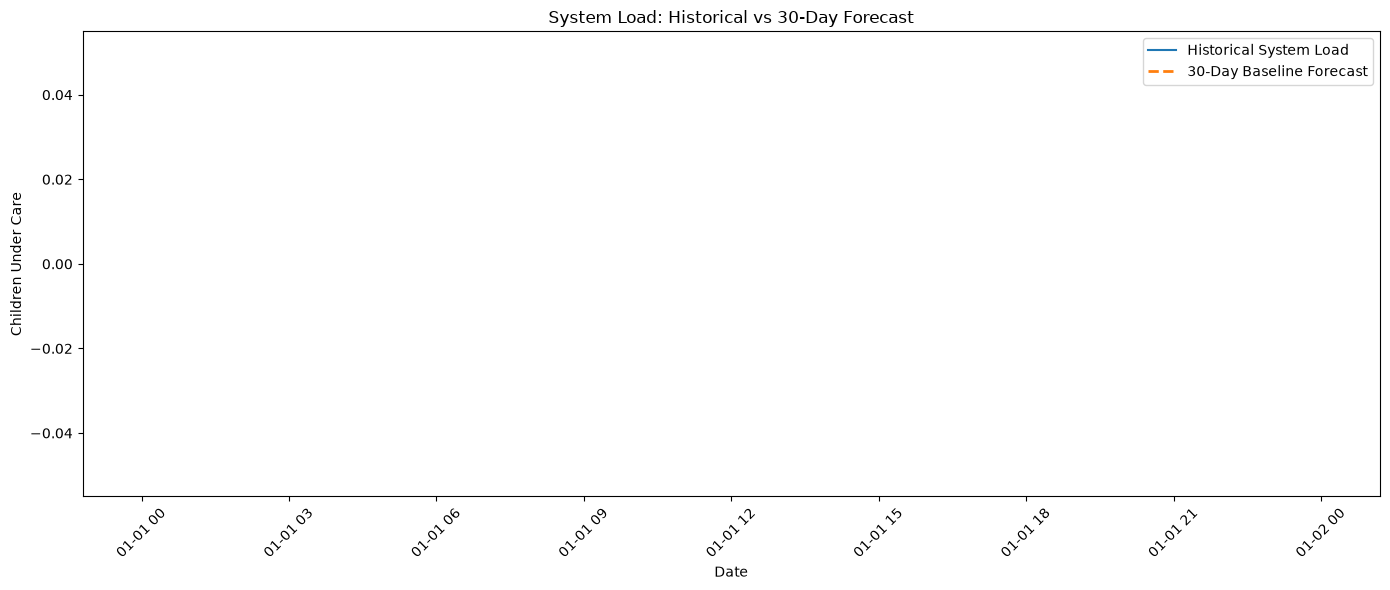

In [75]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Total System Load"],
    label="Historical System Load"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted System Load"],
    linestyle="--",
    linewidth=2,
    label="30-Day Baseline Forecast"
)

plt.title("System Load: Historical vs 30-Day Forecast")
plt.xlabel("Date")
plt.ylabel("Children Under Care")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [76]:
forecast_df.to_csv(
    "../data/processed/30_day_forecast.csv",
    index=False
)

print("✅ Forecast saved successfully!")

✅ Forecast saved successfully!


In [77]:
df["Care Load Growth Rate"] = (
    df["Total System Load"]
    .pct_change() * 100
)

print(
    df[
        ["Date", "Total System Load", "Care Load Growth Rate"]
    ].head(10)
)

        Date  Total System Load  Care Load Growth Rate
0 2023-01-12                NaN                    NaN
1 2023-01-22                NaN                    NaN
2 2023-01-23                NaN                    NaN
3 2023-01-24                NaN                    NaN
4 2023-01-25                NaN                    NaN
5 2023-01-29                NaN                    NaN
6 2023-01-30                NaN                    NaN
7 2023-01-31                NaN                    NaN
8 2023-02-01                NaN                    NaN
9 2023-02-02                NaN                    NaN


In [78]:
print(
    "Average Growth Rate:",
    round(df["Care Load Growth Rate"].mean(), 2),
    "%"
)

print(
    "Maximum Growth Rate:",
    round(df["Care Load Growth Rate"].max(), 2),
    "%"
)

print(
    "Minimum Growth Rate:",
    round(df["Care Load Growth Rate"].min(), 2),
    "%"
)

Average Growth Rate: nan %
Maximum Growth Rate: nan %
Minimum Growth Rate: nan %


In [79]:
df["7-Day Rolling Load"] = (
    df["Total System Load"]
    .rolling(window=7)
    .mean()
)

print(
    df[
        ["Date", "Total System Load", "7-Day Rolling Load"]
    ].tail(10)
)

          Date  Total System Load  7-Day Rolling Load
710 2025-12-08                NaN                 NaN
711 2025-12-09                NaN                 NaN
712 2025-12-10                NaN                 NaN
713 2025-12-11                NaN                 NaN
714 2025-12-14                NaN                 NaN
715 2025-12-15                NaN                 NaN
716 2025-12-16                NaN                 NaN
717 2025-12-17                NaN                 NaN
718 2025-12-18                NaN                 NaN
719 2025-12-21                NaN                 NaN


In [80]:
df["14-Day Rolling Load"] = (
    df["Total System Load"]
    .rolling(window=14)
    .mean()
)

print(
    df[
        ["Date", "Total System Load", "14-Day Rolling Load"]
    ].tail(10)
)

          Date  Total System Load  14-Day Rolling Load
710 2025-12-08                NaN                  NaN
711 2025-12-09                NaN                  NaN
712 2025-12-10                NaN                  NaN
713 2025-12-11                NaN                  NaN
714 2025-12-14                NaN                  NaN
715 2025-12-15                NaN                  NaN
716 2025-12-16                NaN                  NaN
717 2025-12-17                NaN                  NaN
718 2025-12-18                NaN                  NaN
719 2025-12-21                NaN                  NaN


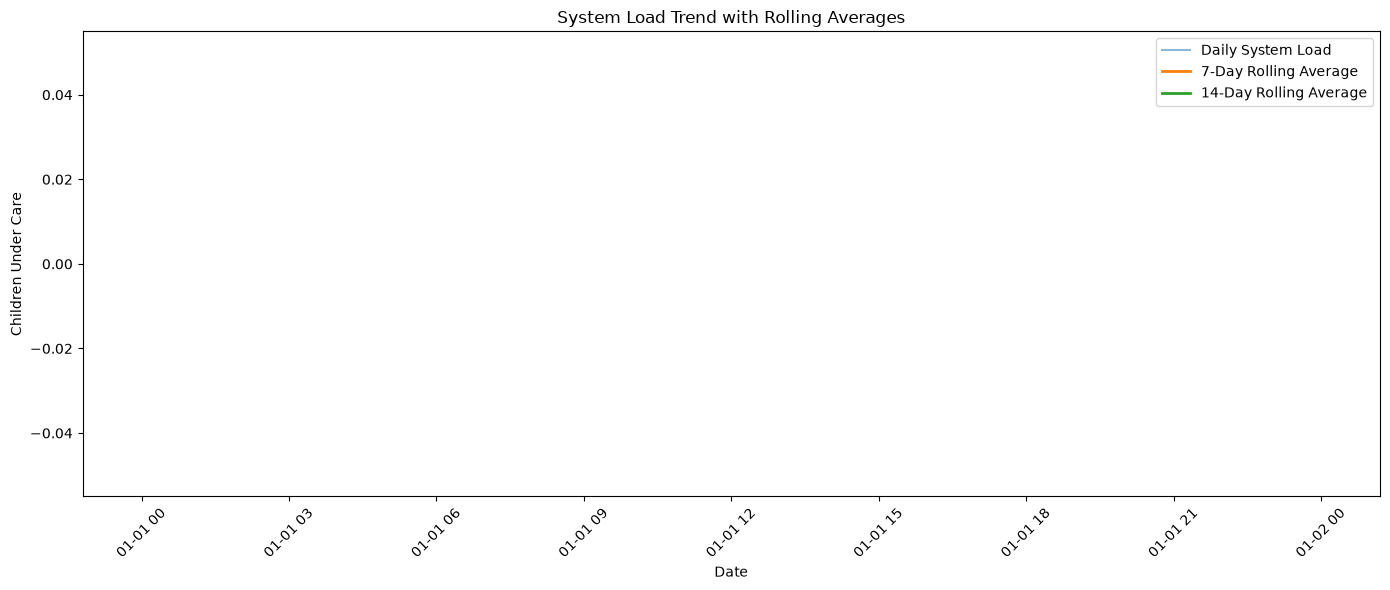

In [81]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Total System Load"],
    label="Daily System Load",
    alpha=0.5
)

plt.plot(
    df["Date"],
    df["7-Day Rolling Load"],
    label="7-Day Rolling Average",
    linewidth=2
)

plt.plot(
    df["Date"],
    df["14-Day Rolling Load"],
    label="14-Day Rolling Average",
    linewidth=2
)

plt.title("System Load Trend with Rolling Averages")
plt.xlabel("Date")
plt.ylabel("Children Under Care")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [82]:
df.to_csv(
    "../data/processed/analytics_data.csv",
    index=False
)

print("✅ Analytics dataset saved successfully!")

✅ Analytics dataset saved successfully!


In [83]:
df["Backlog Indicator"] = (
    df["Net Daily Intake"] > 0
).astype(int)

print(
    df[
        [
            "Date",
            "Net Daily Intake",
            "Backlog Indicator"
        ]
    ].head(15)
)

         Date  Net Daily Intake  Backlog Indicator
0  2023-01-12            -402.0                  0
1  2023-01-22            -188.0                  0
2  2023-01-23            -142.0                  0
3  2023-01-24            -128.0                  0
4  2023-01-25            -139.0                  0
5  2023-01-29            -292.0                  0
6  2023-01-30            -167.0                  0
7  2023-01-31            -122.0                  0
8  2023-02-01            -204.0                  0
9  2023-02-02            -275.0                  0
10 2023-02-05            -327.0                  0
11 2023-02-06            -184.0                  0
12 2023-02-07            -180.0                  0
13 2023-02-08            -148.0                  0
14 2023-02-09            -192.0                  0


In [84]:
df["Backlog Streak"] = (
    df["Backlog Indicator"]
    .groupby(
        (df["Backlog Indicator"] !=
         df["Backlog Indicator"].shift()).cumsum()
    )
    .cumsum()
)

print(
    df[
        [
            "Date",
            "Net Daily Intake",
            "Backlog Indicator",
            "Backlog Streak"
        ]
    ].tail(20)
)

          Date  Net Daily Intake  Backlog Indicator  Backlog Streak
700 2025-11-23              21.0                  1               1
701 2025-11-24              -4.0                  0               0
702 2025-11-25               3.0                  1               1
703 2025-11-27               1.0                  1               2
704 2025-11-30              10.0                  1               3
705 2025-12-01              -5.0                  0               0
706 2025-12-02              -2.0                  0               0
707 2025-12-03               1.0                  1               1
708 2025-12-04              -6.0                  0               0
709 2025-12-07               1.0                  1               1
710 2025-12-08               5.0                  1               2
711 2025-12-09              -1.0                  0               0
712 2025-12-10              -4.0                  0               0
713 2025-12-11              -1.0                

In [85]:
df["Prolonged Backlog"] = (
    df["Backlog Streak"] >= 3
).astype(int)

print(
    "Prolonged backlog records:",
    df["Prolonged Backlog"].sum()
)

Prolonged backlog records: 96


In [86]:
load_threshold = df["Total System Load"].quantile(0.75)

print(
    "High-load threshold:",
    round(load_threshold, 2)
)

High-load threshold: nan


In [87]:
df["Capacity Stress"] = (
    df["Total System Load"] >= load_threshold
).astype(int)

print(
    "Stress days:",
    df["Capacity Stress"].sum()
)

Stress days: 0


In [88]:
df["High Pressure Period"] = (
    (df["Capacity Stress"] == 1) &
    (df["Prolonged Backlog"] == 1)
).astype(int)

print(
    "High-pressure records:",
    df["High Pressure Period"].sum()
)

High-pressure records: 0


In [89]:
stress_periods = df[
    df["High Pressure Period"] == 1
][
    [
        "Date",
        "Total System Load",
        "Net Daily Intake",
        "Backlog Streak",
        "Capacity Stress"
    ]
]

stress_periods.head(20)

,Date,Total System Load,Net Daily Intake,Backlog Streak,Capacity Stress


In [90]:
print("Total reporting days:", len(df))
print("High-load days:", df["Capacity Stress"].sum())
print("Prolonged backlog days:", df["Prolonged Backlog"].sum())
print("High-pressure days:", df["High Pressure Period"].sum())

Total reporting days: 720
High-load days: 0
Prolonged backlog days: 96
High-pressure days: 0


In [91]:
df.to_csv(
    "../data/processed/analytics_data.csv",
    index=False
)

print("✅ Backlog and stress analysis saved!")

✅ Backlog and stress analysis saved!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Date को properly datetime बनाना
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Invalid dates हटाना
df = df.dropna(subset=["Date"]).copy()

# Date sort करना
df = df.sort_values("Date")

print("Rows:", len(df))
print("First Date:", df["Date"].min())
print("Last Date:", df["Date"].max())

NameError: name 'df' is not defined

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import glob
import os

files = glob.glob("../raw/*")

print(files)

[]


In [4]:
df = pd.read_csv("../raw/HHS_Unaccompanied_Alien_Children.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '../raw/HHS_Unaccompanied_Alien_Children.csv'

In [5]:
import os
import glob

print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

print("\nCSV files in parent folder:")
print(glob.glob("../*.csv"))

print("\nFiles in ../raw:")
print(glob.glob("../raw/*"))

Current folder:
c:\Intership\System_Capacity_Care_Load_Analytics\System_Capacity_Care_Load_Analytics\notebooks

Files in current folder:
['01_Data_Cleaning.ipynb', '02_EDA.ipynb', '03_KPI_Analysis.ipynb', '04_Forecasting.ipynb']

CSV files in parent folder:
[]

Files in ../raw:
[]


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.columns.tolist())

Rows: 1170
Columns: 6
['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care']


In [7]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = df.dropna(subset=["Date"]).copy()
df = df.sort_values("Date")

print("Valid dates:", df["Date"].notna().sum())
print("First date:", df["Date"].min())
print("Last date:", df["Date"].max())

Valid dates: 720
First date: 2023-01-12 00:00:00
Last date: 2025-12-21 00:00:00


In [8]:
monthly_forecast = (
    df.set_index("Date")["Total System Load"]
      .resample("MS")
      .mean()
      .dropna()
)

print("Monthly observations:", len(monthly_forecast))
print("First month:", monthly_forecast.index.min())
print("Last month:", monthly_forecast.index.max())

print(monthly_forecast.head())

KeyError: 'Total System Load'

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/analytics_data.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.columns.tolist())

Rows: 720
Columns: 12
['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care', 'Total System Load', 'Net Daily Intake', 'Care Load Growth Rate', '7-Day Rolling Load', '14-Day Rolling Load', 'Backlog Indicator']


In [10]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = df.dropna(subset=["Date"]).copy()
df = df.sort_values("Date")

print("Valid dates:", df["Date"].notna().sum())
print("First Date:", df["Date"].min())
print("Last Date:", df["Date"].max())

Valid dates: 720
First Date: 2023-01-12 00:00:00
Last Date: 2025-12-21 00:00:00


In [11]:
print(df[["Date", "Total System Load"]].head(10))
print()
print("Missing Total System Load:",
      df["Total System Load"].isna().sum())

        Date  Total System Load
0 2023-01-12               6619
1 2023-01-22               7171
2 2023-01-23               7330
3 2023-01-24               7475
4 2023-01-25               7560
5 2023-01-29               7517
6 2023-01-30               7797
7 2023-01-31               7839
8 2023-02-01               7935
9 2023-02-02               7892

Missing Total System Load: 0


In [12]:
monthly_forecast = (
    df.set_index("Date")["Total System Load"]
      .resample("MS")
      .mean()
      .dropna()
)

print("Monthly observations:", len(monthly_forecast))
print("First month:", monthly_forecast.index.min())
print("Last month:", monthly_forecast.index.max())
print(monthly_forecast)

Monthly observations: 36
First month: 2023-01-01 00:00:00
Last month: 2025-12-01 00:00:00
Date
2023-01-01     7413.500000
2023-02-01     7967.105263
2023-03-01     8190.473684
2023-04-01     8092.857143
2023-05-01     8404.090909
2023-06-01     6282.100000
2023-07-01     7073.380952
2023-08-01     9585.100000
2023-09-01    10992.368421
2023-10-01    10308.227273
2023-11-01     9909.600000
2023-12-01    11255.263158
2024-01-01     9021.636364
2024-02-01     8766.800000
2024-03-01     8703.857143
2024-04-01     7336.318182
2024-05-01     7836.047619
2024-06-01     7691.476190
2024-07-01     6498.761905
2024-08-01     6258.736842
2024-09-01     6452.636364
2024-10-01     6276.285714
2024-11-01     6151.421053
2024-12-01     6690.409091
2025-01-01     5080.045455
2025-02-01     2804.210526
2025-03-01     2185.909091
2025-04-01     2298.000000
2025-05-01     2439.777778
2025-06-01     2511.470588
2025-07-01     2201.142857
2025-08-01     2026.900000
2025-09-01     2118.045455
2025-10-01    

In [13]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA model
model = ARIMA(
    monthly_forecast,
    order=(1, 1, 1)
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      Total System Load   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -289.208
Date:                Sun, 23 Aug 2026   AIC                            584.417
Time:                        19:42:32   BIC                            589.083
Sample:                    01-01-2023   HQIC                           586.027
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7212      0.101     -7.157      0.000      -0.919      -0.524
ma.L1          0.9998      0.209      4.784      0.000       0.590       1.409
sigma2      7.931e+05   2.64e-07   3.01e+12      0.0

c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [14]:
model = ARIMA(
    monthly_forecast,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:      Total System Load   No. Observations:                   36
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -282.069
Date:                Sun, 23 Aug 2026   AIC                            572.138
Time:                        19:42:50   BIC                            578.243
Sample:                    01-01-2023   HQIC                           574.220
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6220.3190   4238.028      1.468      0.142   -2086.062    1.45e+04
ar.L1          0.9281      0.142      6.521      0.000       0.649       1.207
ma.L1          0.2762      0.183      1.513      0.1

In [15]:
forecast_steps = 6

forecast_result = model_fit.forecast(
    steps=forecast_steps
)

print("Forecast:")
print(forecast_result)

Forecast:
2026-01-01    2718.966213
2026-02-01    2970.635260
2026-03-01    3204.214926
2026-04-01    3421.005432
2026-05-01    3622.213543
2026-06-01    3808.959286
Freq: MS, Name: predicted_mean, dtype: float64


In [16]:
future_dates = pd.date_range(
    start=monthly_forecast.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast Total System Load": forecast_result.values
})

print(forecast_df)

        Date  Forecast Total System Load
0 2026-01-01                 2718.966213
1 2026-02-01                 2970.635260
2 2026-03-01                 3204.214926
3 2026-04-01                 3421.005432
4 2026-05-01                 3622.213543
5 2026-06-01                 3808.959286


In [1]:
forecast_steps = 6

forecast_result = model_fit.forecast(
    steps=forecast_steps
)

print("Forecast Values:")
print(forecast_result)

NameError: name 'model_fit' is not defined

In [2]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    monthly_forecast,
    order=(1, 1, 1)
)

model_fit = model.fit()

print(model_fit.summary())

NameError: name 'monthly_forecast' is not defined

In [3]:
model = ARIMA(
    monthly_forecast,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()

print(model_fit.summary())

NameError: name 'monthly_forecast' is not defined

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Load processed analytics data
df = pd.read_csv("../data/processed/analytics_data.csv")

# 2. Convert Date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# 3. Remove invalid dates
df = df.dropna(subset=["Date"]).copy()

# 4. Sort by Date
df = df.sort_values("Date")

# 5. Create monthly Total System Load
monthly_forecast = (
    df.set_index("Date")["Total System Load"]
      .resample("MS")
      .mean()
      .dropna()
)

print("Monthly observations:", len(monthly_forecast))
print("First month:", monthly_forecast.index.min())
print("Last month:", monthly_forecast.index.max())

# 6. ARIMA model
model = ARIMA(
    monthly_forecast,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# 7. Fit model
model_fit = model.fit()

print("\nARIMA Model Successfully Fitted!")
print(model_fit.summary())

Monthly observations: 36
First month: 2023-01-01 00:00:00
Last month: 2025-12-01 00:00:00

ARIMA Model Successfully Fitted!
                               SARIMAX Results                                
Dep. Variable:      Total System Load   No. Observations:                   36
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -282.069
Date:                Mon, 24 Aug 2026   AIC                            572.138
Time:                        18:40:18   BIC                            578.243
Sample:                    01-01-2023   HQIC                           574.220
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6220.3190   4238.028      1.468      0.142   -2086.062    1.45e+04
ar.L1  

In [5]:
forecast_steps = 6

forecast_result = model_fit.forecast(
    steps=forecast_steps
)

print("6-Month Forecast:")
print(forecast_result)

6-Month Forecast:
2026-01-01    2718.966213
2026-02-01    2970.635260
2026-03-01    3204.214926
2026-04-01    3421.005432
2026-05-01    3622.213543
2026-06-01    3808.959286
Freq: MS, Name: predicted_mean, dtype: float64


In [6]:
future_dates = pd.date_range(
    start=monthly_forecast.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast Total System Load": forecast_result.values
})

print(forecast_df)

        Date  Forecast Total System Load
0 2026-01-01                 2718.966213
1 2026-02-01                 2970.635260
2 2026-03-01                 3204.214926
3 2026-04-01                 3421.005432
4 2026-05-01                 3622.213543
5 2026-06-01                 3808.959286


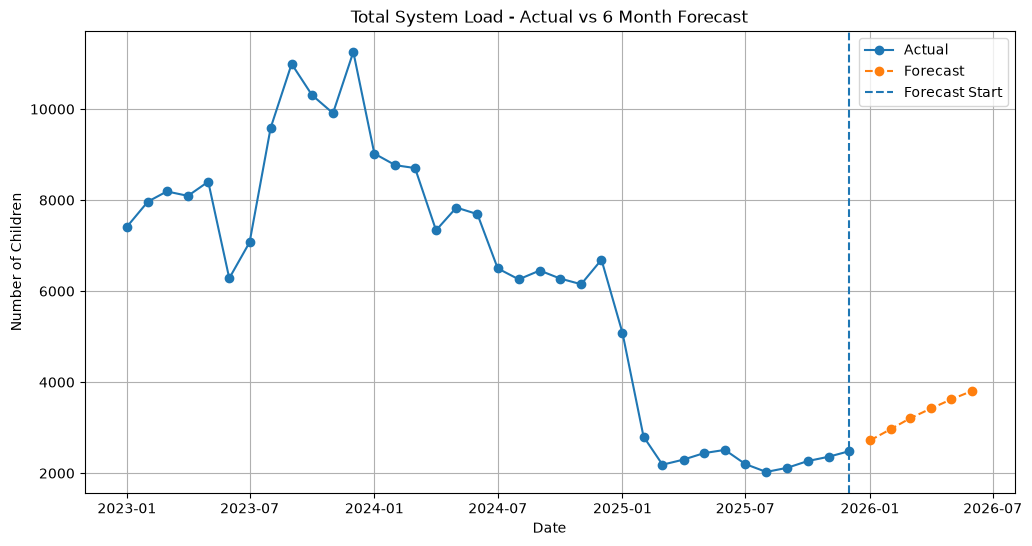

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_forecast.index,
    monthly_forecast.values,
    marker="o",
    label="Actual"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast Total System Load"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.axvline(
    monthly_forecast.index[-1],
    linestyle="--",
    label="Forecast Start"
)

plt.title("Total System Load - Actual vs 6 Month Forecast")
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
# Last 6 months को test data रखें
train = monthly_forecast.iloc[:-6]
test = monthly_forecast.iloc[-6:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("\nTest Data:")
print(test)

Training observations: 30
Testing observations: 6

Test Data:
Date
2025-07-01    2201.142857
2025-08-01    2026.900000
2025-09-01    2118.045455
2025-10-01    2265.380952
2025-11-01    2360.684211
2025-12-01    2481.466667
Freq: MS, Name: Total System Load, dtype: float64


In [9]:
validation_model = ARIMA(
    train,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

validation_fit = validation_model.fit()

print("Validation model fitted successfully!")

Validation model fitted successfully!


In [10]:
validation_forecast = validation_fit.forecast(
    steps=len(test)
)

validation_forecast.index = test.index

print("Actual vs Predicted:")
print(
    pd.DataFrame({
        "Actual": test.values,
        "Predicted": validation_forecast.values
    }, index=test.index)
)

Actual vs Predicted:
                 Actual    Predicted
Date                                
2025-07-01  2201.142857  2873.591812
2025-08-01  2026.900000  3296.200880
2025-09-01  2118.045455  3675.694570
2025-10-01  2265.380952  4016.471596
2025-11-01  2360.684211  4322.481904
2025-12-01  2481.466667  4597.272460


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    test,
    validation_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        validation_forecast
    )
)

mape = np.mean(
    np.abs((test.values - validation_forecast.values) / test.values)
) * 100

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE: 1554.68
RMSE: 1626.92
MAPE: 68.73 %


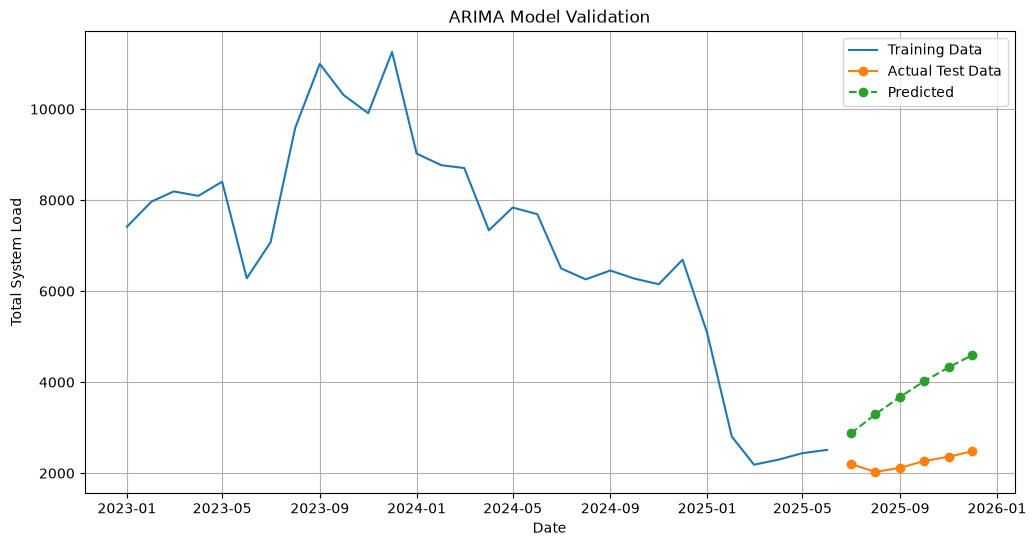

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(
    train.index,
    train.values,
    label="Training Data"
)

plt.plot(
    test.index,
    test.values,
    marker="o",
    label="Actual Test Data"
)

plt.plot(
    validation_forecast.index,
    validation_forecast.values,
    marker="o",
    linestyle="--",
    label="Predicted"
)

plt.title("ARIMA Model Validation")
plt.xlabel("Date")
plt.ylabel("Total System Load")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Final 6-month forecast

forecast_steps = 6

final_forecast = model_fit.forecast(
    steps=forecast_steps
)

future_dates = pd.date_range(
    start=monthly_forecast.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq="MS"
)

final_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast Total System Load": final_forecast.values
})

print("===== FINAL 6-MONTH FORECAST =====")
print(final_forecast_df)

===== FINAL 6-MONTH FORECAST =====
        Date  Forecast Total System Load
0 2026-01-01                 2718.966213
1 2026-02-01                 2970.635260
2 2026-03-01                 3204.214926
3 2026-04-01                 3421.005432
4 2026-05-01                 3622.213543
5 2026-06-01                 3808.959286


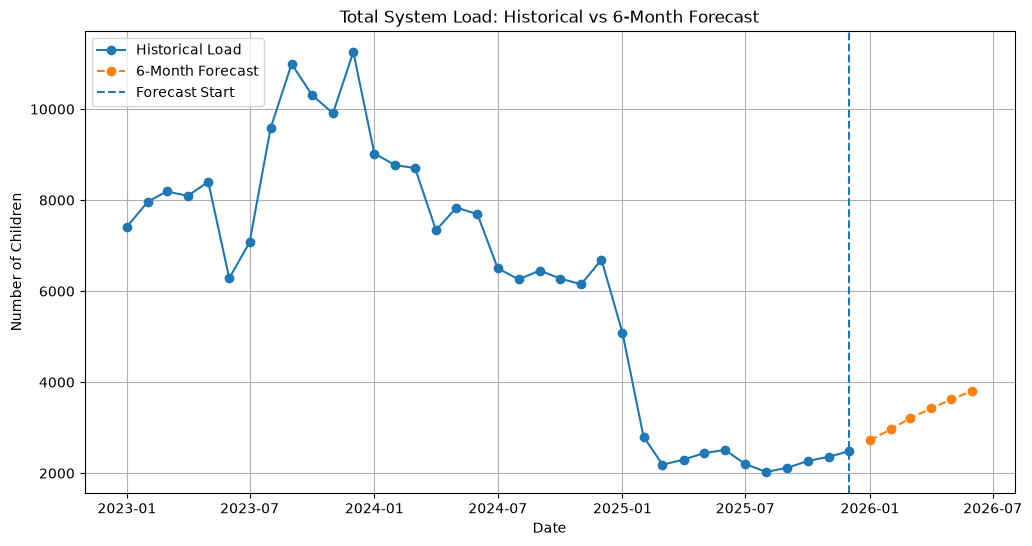

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_forecast.index,
    monthly_forecast.values,
    marker="o",
    label="Historical Load"
)

plt.plot(
    final_forecast_df["Date"],
    final_forecast_df["Forecast Total System Load"],
    marker="o",
    linestyle="--",
    label="6-Month Forecast"
)

plt.axvline(
    monthly_forecast.index[-1],
    linestyle="--",
    label="Forecast Start"
)

plt.title("Total System Load: Historical vs 6-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
final_forecast_df.to_csv(
    "../data/processed/6_month_forecast.csv",
    index=False
)

print("Forecast CSV saved successfully!")
print("../data/processed/6_month_forecast.csv")

Forecast CSV saved successfully!
../data/processed/6_month_forecast.csv


In [16]:
print("========== FINAL PROJECT INSIGHTS ==========")

# System Load
peak_load = df["Total System Load"].max()
lowest_load = df["Total System Load"].min()
avg_load = df["Total System Load"].mean()

peak_load_date = df.loc[
    df["Total System Load"].idxmax(), "Date"
]

# HHS Care
peak_hhs = df["Children in HHS Care"].max()
avg_hhs = df["Children in HHS Care"].mean()

peak_hhs_date = df.loc[
    df["Children in HHS Care"].idxmax(), "Date"
]

# Discharges
total_discharge = df["Children discharged from HHS Care"].sum()
avg_discharge = df["Children discharged from HHS Care"].mean()

# Net Intake
avg_intake = df["Net Daily Intake"].mean()
positive_days = (df["Net Daily Intake"] > 0).sum()
negative_days = (df["Net Daily Intake"] < 0).sum()

print("\n--- System Load ---")
print("Average System Load:", round(avg_load, 2))
print("Peak System Load:", peak_load)
print("Peak Load Date:", peak_load_date.date())
print("Lowest System Load:", lowest_load)

print("\n--- HHS Care ---")
print("Average HHS Care:", round(avg_hhs, 2))
print("Peak HHS Care:", peak_hhs)
print("Peak HHS Care Date:", peak_hhs_date.date())

print("\n--- HHS Discharges ---")
print("Total Discharges:", int(total_discharge))
print("Average Daily Discharges:", round(avg_discharge, 2))

print("\n--- Net Daily Intake ---")
print("Average Net Intake:", round(avg_intake, 2))
print("Positive Intake Days:", positive_days)
print("Negative Intake Days:", negative_days)

print("\n--- Forecast ---")
print(final_forecast_df)

========== FINAL PROJECT INSIGHTS ==========

--- System Load ---
Average System Load: 6232.77
Peak System Load: 11762
Peak Load Date: 2023-12-20
Lowest System Load: 2002

--- HHS Care ---
Average HHS Care: 6061.28
Peak HHS Care: 11516
Peak HHS Care Date: 2023-12-20

--- HHS Discharges ---
Total Discharges: 124853
Average Daily Discharges: 173.41

--- Net Daily Intake ---
Average Net Intake: -44.74
Positive Intake Days: 238
Negative Intake Days: 475

--- Forecast ---
        Date  Forecast Total System Load
0 2026-01-01                 2718.966213
1 2026-02-01                 2970.635260
2 2026-03-01                 3204.214926
3 2026-04-01                 3421.005432
4 2026-05-01                 3622.213543
5 2026-06-01                 3808.959286


In [17]:
forecast_start = final_forecast_df["Forecast Total System Load"].iloc[0]
forecast_end = final_forecast_df["Forecast Total System Load"].iloc[-1]

forecast_change = forecast_end - forecast_start
forecast_change_pct = (forecast_change / forecast_start) * 100

print("Forecast Start:", round(forecast_start, 2))
print("Forecast End:", round(forecast_end, 2))
print("Forecast Change:", round(forecast_change, 2))
print("Forecast Change %:", round(forecast_change_pct, 2), "%")

Forecast Start: 2718.97
Forecast End: 3808.96
Forecast Change: 1089.99
Forecast Change %: 40.09 %


In [18]:
print("========== FINAL RECOMMENDATIONS ==========")

print("""
1. Capacity Planning:
   Historical peak system load was 11,762 children.
   Future capacity planning should consider high-load periods
   and maintain sufficient operational buffer.

2. HHS Care Management:
   Peak HHS care reached 11,516 children.
   HHS care load should be continuously monitored to identify
   periods of high operational demand.

3. Intake Monitoring:
   There were 238 positive net intake days and 475 negative
   net intake days. Positive intake periods should be monitored
   as potential backlog-pressure periods.

4. Early Warning System:
   Net Daily Intake can be used as an early indicator of
   increasing system pressure.

5. Forecast-Based Planning:
   ARIMA forecasting estimates an increase from 2,718.97
   children in January 2026 to 3,808.96 in June 2026.

6. Resource Allocation:
   Forecasted increases should be considered when planning
   staffing, shelter/care capacity, transportation and
   operational resources.

7. Continuous Monitoring:
   KPI dashboards should be updated regularly so that
   decision-makers can identify changes in system load,
   intake pressure and care demand.
""")

========== FINAL RECOMMENDATIONS ==========

1. Capacity Planning:
   Historical peak system load was 11,762 children.
   Future capacity planning should consider high-load periods
   and maintain sufficient operational buffer.

2. HHS Care Management:
   Peak HHS care reached 11,516 children.
   HHS care load should be continuously monitored to identify
   periods of high operational demand.

3. Intake Monitoring:
   There were 238 positive net intake days and 475 negative
   net intake days. Positive intake periods should be monitored
   as potential backlog-pressure periods.

4. Early Warning System:
   Net Daily Intake can be used as an early indicator of
   increasing system pressure.

5. Forecast-Based Planning:
   ARIMA forecasting estimates an increase from 2,718.97
   children in January 2026 to 3,808.96 in June 2026.

6. Resource Allocation:
   Forecasted increases should be considered when planning
   staffing, shelter/care capacity, transportation and
   operational resourc

In [19]:
print("=" * 70)
print("SYSTEM CAPACITY & CARE LOAD ANALYTICS")
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print("""
PROJECT OBJECTIVE
-----------------
The objective of this project is to analyze system capacity,
HHS care load, CBP custody, discharges and daily intake pressure
for Unaccompanied Children and use historical data to forecast
future system load.

DATASET
-------
Total observations: 720
Date range: January 2023 to December 2025
Monthly observations: 36

KEY FINDINGS
------------
1. Peak Total System Load:
   11,762 children on December 20, 2023.

2. Average Total System Load:
   6,232.77 children.

3. Peak HHS Care:
   11,516 children on December 20, 2023.

4. Average HHS Care:
   6,061.28 children.

5. Total HHS Discharges:
   124,853.

6. Average Daily HHS Discharges:
   173.41 children.

7. Average Net Daily Intake:
   -44.74 children.

8. Positive Net Intake Days:
   238 days.

9. Negative Net Intake Days:
   475 days.

FORECASTING
-----------
ARIMA(1,0,1) was used to forecast future Total System Load.

The forecast indicates:

January 2026: 2,718.97
June 2026: 3,808.96

Expected increase during the forecast period:
40.09%

RECOMMENDATIONS
---------------
1. Use system-load KPIs for regular capacity monitoring.
2. Monitor positive Net Daily Intake as an early warning indicator.
3. Use forecasting results for resource and capacity planning.
4. Monitor HHS care load separately from overall system load.
5. Maintain sufficient operational capacity during high-load periods.
6. Regularly update the analytics dashboard with new data.

CONCLUSION
----------
The analysis provides a data-driven view of system capacity,
HHS care demand and intake pressure. Historical trends show
substantial variation in system load, with the highest levels
occurring during 2023. The ARIMA forecast indicates a gradual
increase in system load during the first six months of 2026.

The results can support capacity planning, resource allocation,
operational monitoring and early identification of increasing
system pressure.
""")

print("=" * 70)
print("PROJECT ANALYSIS COMPLETED")
print("=" * 70)

SYSTEM CAPACITY & CARE LOAD ANALYTICS
FINAL PROJECT SUMMARY

PROJECT OBJECTIVE
-----------------
The objective of this project is to analyze system capacity,
HHS care load, CBP custody, discharges and daily intake pressure
for Unaccompanied Children and use historical data to forecast
future system load.

DATASET
-------
Total observations: 720
Date range: January 2023 to December 2025
Monthly observations: 36

KEY FINDINGS
------------
1. Peak Total System Load:
   11,762 children on December 20, 2023.

2. Average Total System Load:
   6,232.77 children.

3. Peak HHS Care:
   11,516 children on December 20, 2023.

4. Average HHS Care:
   6,061.28 children.

5. Total HHS Discharges:
   124,853.

6. Average Daily HHS Discharges:
   173.41 children.

7. Average Net Daily Intake:
   -44.74 children.

8. Positive Net Intake Days:
   238 days.

9. Negative Net Intake Days:
   475 days.

FORECASTING
-----------
ARIMA(1,0,1) was used to forecast future Total System Load.

The forecast indicat

In [20]:
# ==========================================
# STEP 16: FINAL DASHBOARD DATA
# ==========================================

# Monthly dashboard data
dashboard_monthly = pd.DataFrame({
    "Date": monthly_forecast.index,
    "Total System Load": monthly_forecast.values
})

# Add monthly HHS Care
monthly_hhs = (
    df.set_index("Date")["Children in HHS Care"]
    .resample("MS")
    .mean()
)

dashboard_monthly["HHS Care"] = monthly_hhs.values

# Add monthly HHS Discharges
monthly_discharge = (
    df.set_index("Date")["Children discharged from HHS Care"]
    .resample("MS")
    .mean()
)

dashboard_monthly["HHS Discharges"] = monthly_discharge.values

# Add monthly Net Intake
monthly_intake = (
    df.set_index("Date")["Net Daily Intake"]
    .resample("MS")
    .mean()
)

dashboard_monthly["Net Daily Intake"] = monthly_intake.values

print("===== FINAL DASHBOARD DATA =====")
print(dashboard_monthly.head())

print("\nRows:", len(dashboard_monthly))
print("Columns:", dashboard_monthly.columns.tolist())

===== FINAL DASHBOARD DATA =====
        Date  Total System Load     HHS Care  HHS Discharges  Net Daily Intake
0 2023-01-01        7413.500000  7369.625000      232.000000       -197.500000
1 2023-02-01        7967.105263  7795.789474      272.789474       -134.000000
2 2023-03-01        8190.473684  7945.368421      282.894737       -104.000000
3 2023-04-01        8092.857143  7842.666667      269.904762        -81.000000
4 2023-05-01        8404.090909  8187.136364      284.363636       -119.727273

Rows: 36
Columns: ['Date', 'Total System Load', 'HHS Care', 'HHS Discharges', 'Net Daily Intake']


In [21]:
print(dashboard_monthly.isnull().sum())

Date                 0
Total System Load    0
HHS Care             0
HHS Discharges       0
Net Daily Intake     0
dtype: int64


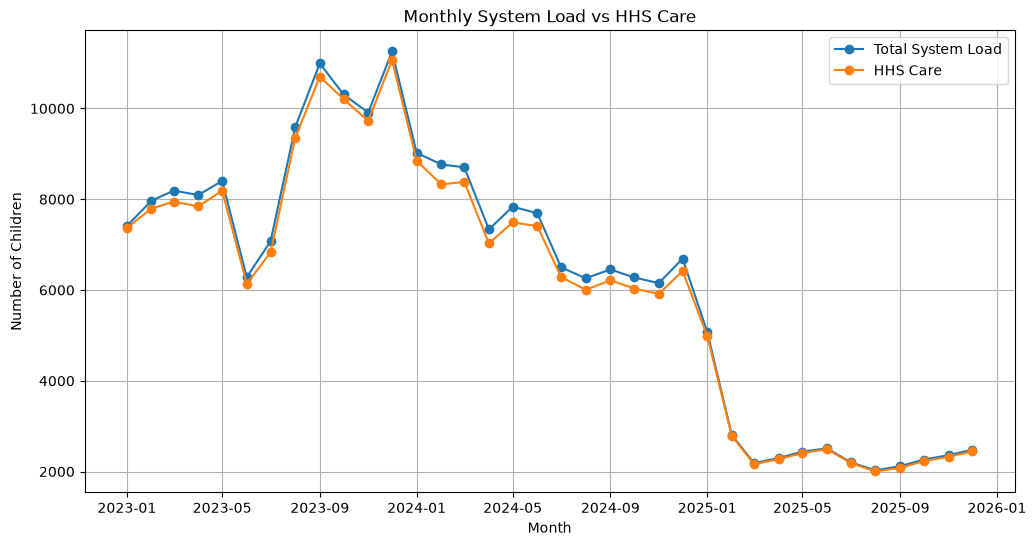

In [22]:
plt.figure(figsize=(12, 6))

plt.plot(
    dashboard_monthly["Date"],
    dashboard_monthly["Total System Load"],
    marker="o",
    label="Total System Load"
)

plt.plot(
    dashboard_monthly["Date"],
    dashboard_monthly["HHS Care"],
    marker="o",
    label="HHS Care"
)

plt.title("Monthly System Load vs HHS Care")
plt.xlabel("Month")
plt.ylabel("Number of Children")
plt.legend()
plt.grid(True)

plt.show()

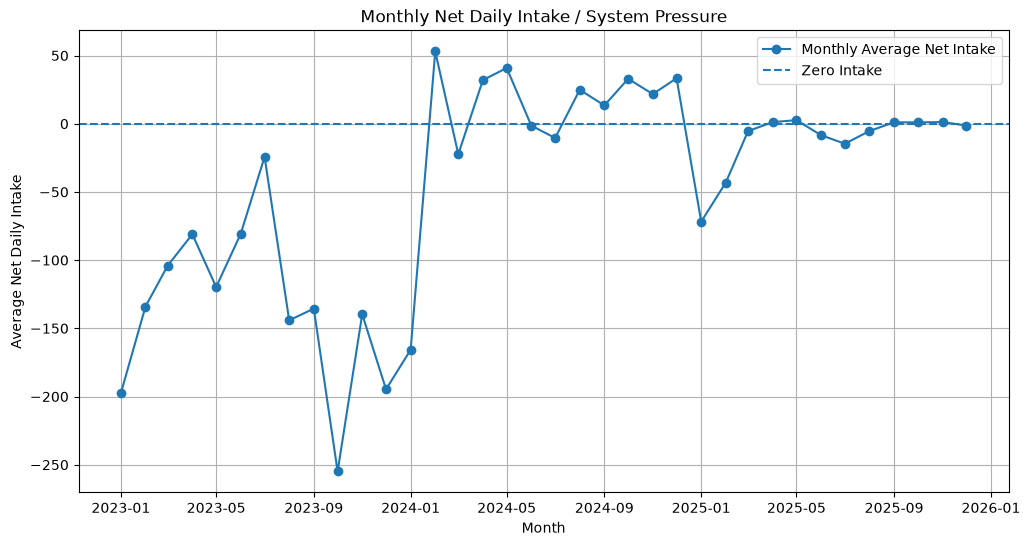

In [23]:
# ==========================================
# STEP 16.2: NET DAILY INTAKE PRESSURE
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    dashboard_monthly["Date"],
    dashboard_monthly["Net Daily Intake"],
    marker="o",
    label="Monthly Average Net Intake"
)

plt.axhline(
    y=0,
    linestyle="--",
    label="Zero Intake"
)

plt.title("Monthly Net Daily Intake / System Pressure")
plt.xlabel("Month")
plt.ylabel("Average Net Daily Intake")
plt.legend()
plt.grid(True)

plt.show()

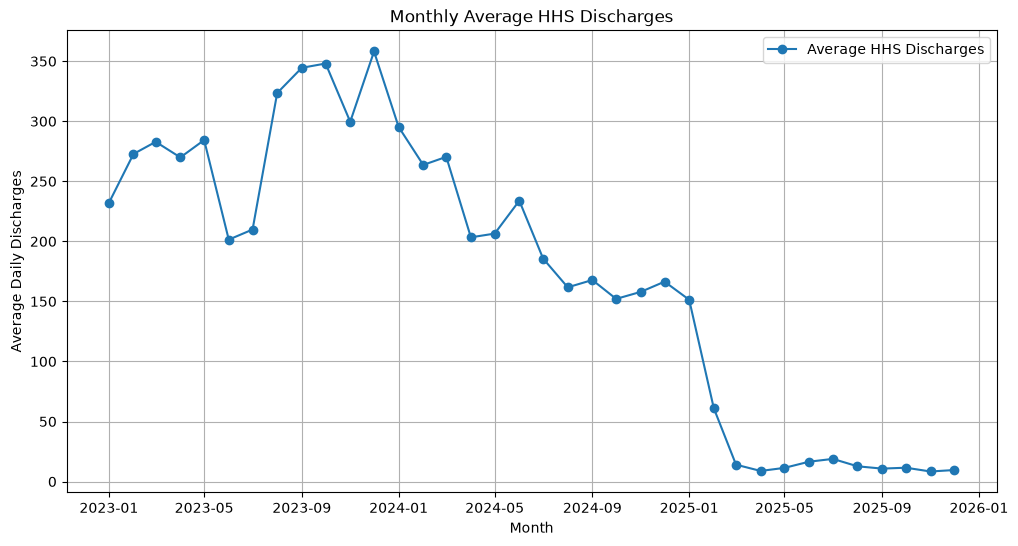

In [24]:
# ==========================================
# STEP 16.3: HHS DISCHARGE TREND
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    dashboard_monthly["Date"],
    dashboard_monthly["HHS Discharges"],
    marker="o",
    label="Average HHS Discharges"
)

plt.title("Monthly Average HHS Discharges")
plt.xlabel("Month")
plt.ylabel("Average Daily Discharges")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
dashboard_monthly.to_csv(
    "../data/processed/monthly_dashboard_data.csv",
    index=False
)

print("Monthly dashboard data saved successfully!")

Monthly dashboard data saved successfully!


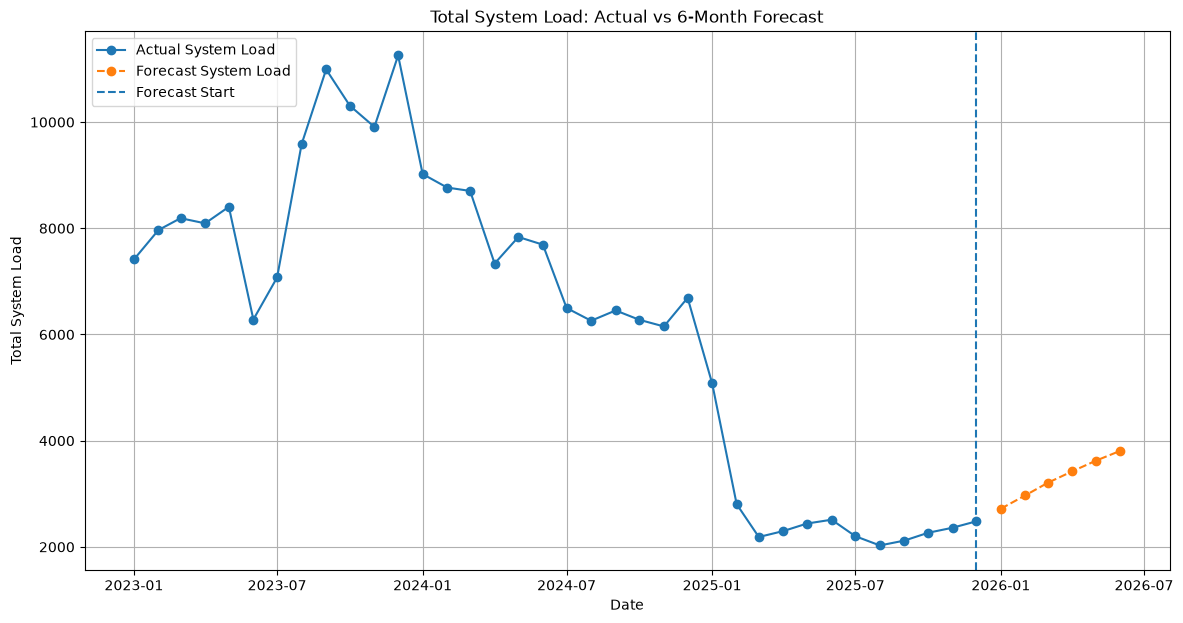

In [26]:
# ==========================================
# STEP 17: ACTUAL VS FORECAST
# ==========================================

plt.figure(figsize=(14, 7))

# Historical data
plt.plot(
    monthly_forecast.index,
    monthly_forecast.values,
    marker="o",
    label="Actual System Load"
)

# Forecast data
plt.plot(
    final_forecast_df["Date"],
    final_forecast_df["Forecast Total System Load"],
    marker="o",
    linestyle="--",
    label="Forecast System Load"
)

# Forecast starting point
plt.axvline(
    monthly_forecast.index[-1],
    linestyle="--",
    label="Forecast Start"
)

plt.title("Total System Load: Actual vs 6-Month Forecast")
plt.xlabel("Date")
plt.ylabel("Total System Load")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
# ==========================================
# FORECAST SUMMARY
# ==========================================

forecast_summary = final_forecast_df.copy()

forecast_summary["Change from Previous Month"] = (
    forecast_summary["Forecast Total System Load"].diff()
)

forecast_summary["Growth %"] = (
    forecast_summary["Forecast Total System Load"]
    .pct_change() * 100
)

print("===== FORECAST SUMMARY =====")
print(forecast_summary)

===== FORECAST SUMMARY =====
        Date  Forecast Total System Load  Change from Previous Month  Growth %
0 2026-01-01                 2718.966213                         NaN       NaN
1 2026-02-01                 2970.635260                  251.669048  9.256056
2 2026-03-01                 3204.214926                  233.579666  7.862953
3 2026-04-01                 3421.005432                  216.790506  6.765792
4 2026-05-01                 3622.213543                  201.208112  5.881549
5 2026-06-01                 3808.959286                  186.745743  5.155570


In [28]:
forecast_summary.to_csv(
    "../data/processed/final_forecast_summary.csv",
    index=False
)

print("Final forecast summary saved successfully!")

Final forecast summary saved successfully!


In [29]:
# ==========================================
# STEP 18: FINAL KPI DASHBOARD
# ==========================================

peak_load = df["Total System Load"].max()
avg_load = df["Total System Load"].mean()
lowest_load = df["Total System Load"].min()

peak_hhs = df["Children in HHS Care"].max()
avg_hhs = df["Children in HHS Care"].mean()

total_discharge = df["Children discharged from HHS Care"].sum()
avg_discharge = df["Children discharged from HHS Care"].mean()

avg_net_intake = df["Net Daily Intake"].mean()

pressure_days = (df["Net Daily Intake"] > 0).sum()
total_days = len(df)
pressure_percentage = (pressure_days / total_days) * 100

forecast_start = final_forecast_df[
    "Forecast Total System Load"
].iloc[0]

forecast_end = final_forecast_df[
    "Forecast Total System Load"
].iloc[-1]

forecast_change_pct = (
    (forecast_end - forecast_start)
    / forecast_start
) * 100


kpi_dashboard = pd.DataFrame({
    "KPI": [
        "Peak System Load",
        "Average System Load",
        "Lowest System Load",
        "Peak HHS Care",
        "Average HHS Care",
        "Total HHS Discharges",
        "Average Daily Discharges",
        "Average Net Daily Intake",
        "Pressure Days",
        "Pressure Days %",
        "Jan 2026 Forecast",
        "Jun 2026 Forecast",
        "Forecast Change %"
    ],
    
    "Value": [
        peak_load,
        avg_load,
        lowest_load,
        peak_hhs,
        avg_hhs,
        total_discharge,
        avg_discharge,
        avg_net_intake,
        pressure_days,
        pressure_percentage,
        forecast_start,
        forecast_end,
        forecast_change_pct
    ]
})

print("========== FINAL KPI DASHBOARD ==========")
print(kpi_dashboard)

========== FINAL KPI DASHBOARD ==========
                         KPI          Value
0           Peak System Load   11762.000000
1        Average System Load    6232.769444
2         Lowest System Load    2002.000000
3              Peak HHS Care   11516.000000
4           Average HHS Care    6061.275000
5       Total HHS Discharges  124853.000000
6   Average Daily Discharges     173.406944
7   Average Net Daily Intake     -44.738889
8              Pressure Days     238.000000
9            Pressure Days %      33.055556
10         Jan 2026 Forecast    2718.966213
11         Jun 2026 Forecast    3808.959286
12         Forecast Change %      40.088511


In [30]:
kpi_dashboard.to_csv(
    "../data/processed/final_kpi_dashboard.csv",
    index=False
)

print("Final KPI dashboard saved successfully!")

Final KPI dashboard saved successfully!


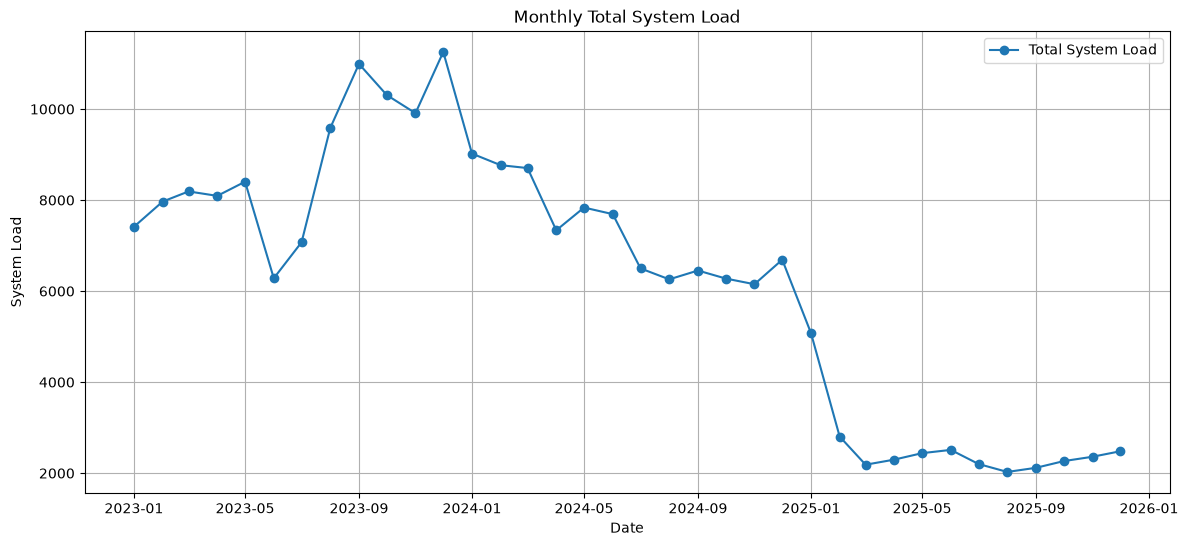

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(
    dashboard_monthly["Date"],
    dashboard_monthly["Total System Load"],
    marker="o",
    label="Total System Load"
)

plt.title("Monthly Total System Load")
plt.xlabel("Date")
plt.ylabel("System Load")
plt.legend()
plt.grid(True)

plt.show()

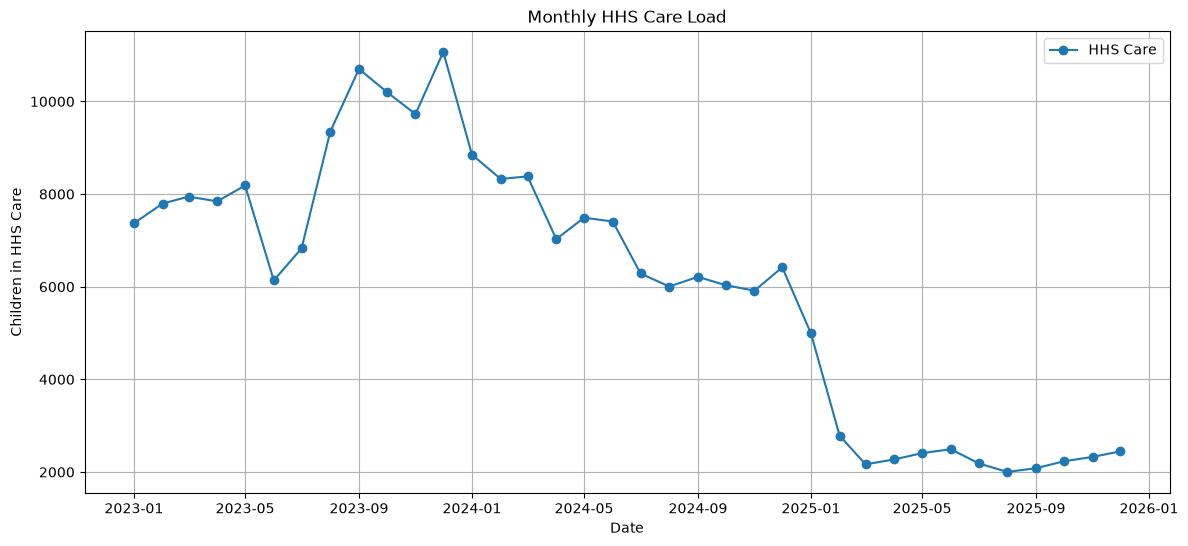

In [32]:
plt.figure(figsize=(14, 6))

plt.plot(
    dashboard_monthly["Date"],
    dashboard_monthly["HHS Care"],
    marker="o",
    label="HHS Care"
)

plt.title("Monthly HHS Care Load")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(True)

plt.show()

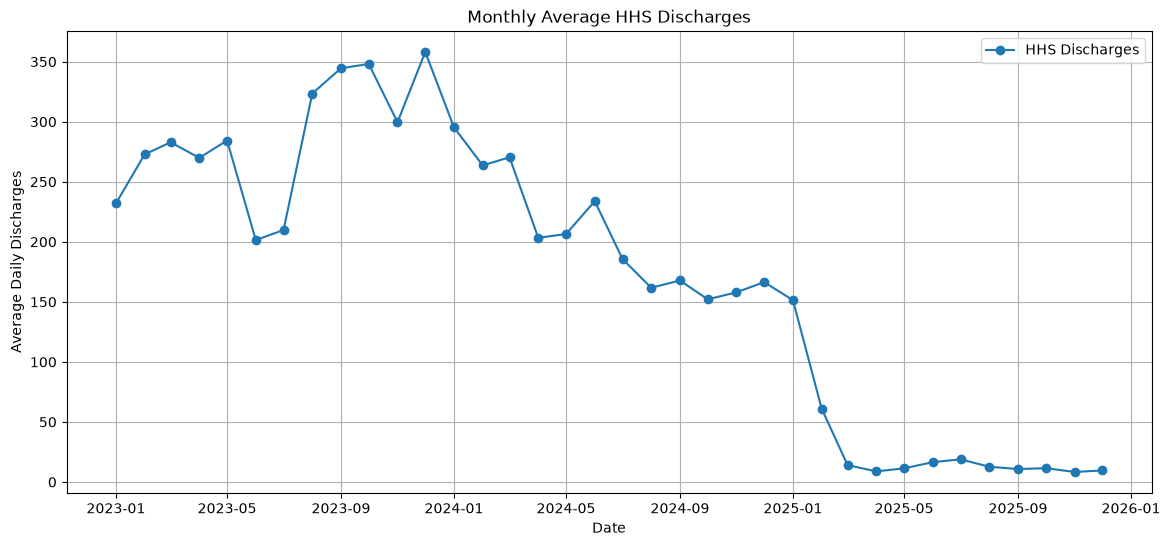

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(
    dashboard_monthly["Date"],
    dashboard_monthly["HHS Discharges"],
    marker="o",
    label="HHS Discharges"
)

plt.title("Monthly Average HHS Discharges")
plt.xlabel("Date")
plt.ylabel("Average Daily Discharges")
plt.legend()
plt.grid(True)

plt.show()

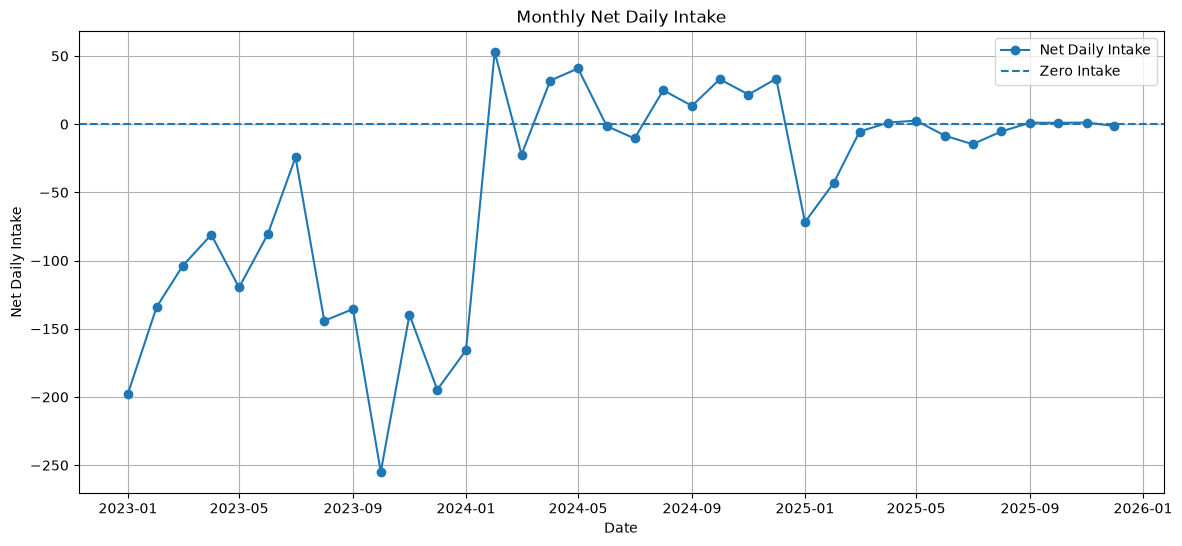

In [34]:
plt.figure(figsize=(14, 6))

plt.plot(
    dashboard_monthly["Date"],
    dashboard_monthly["Net Daily Intake"],
    marker="o",
    label="Net Daily Intake"
)

plt.axhline(
    0,
    linestyle="--",
    label="Zero Intake"
)

plt.title("Monthly Net Daily Intake")
plt.xlabel("Date")
plt.ylabel("Net Daily Intake")
plt.legend()
plt.grid(True)

plt.show()

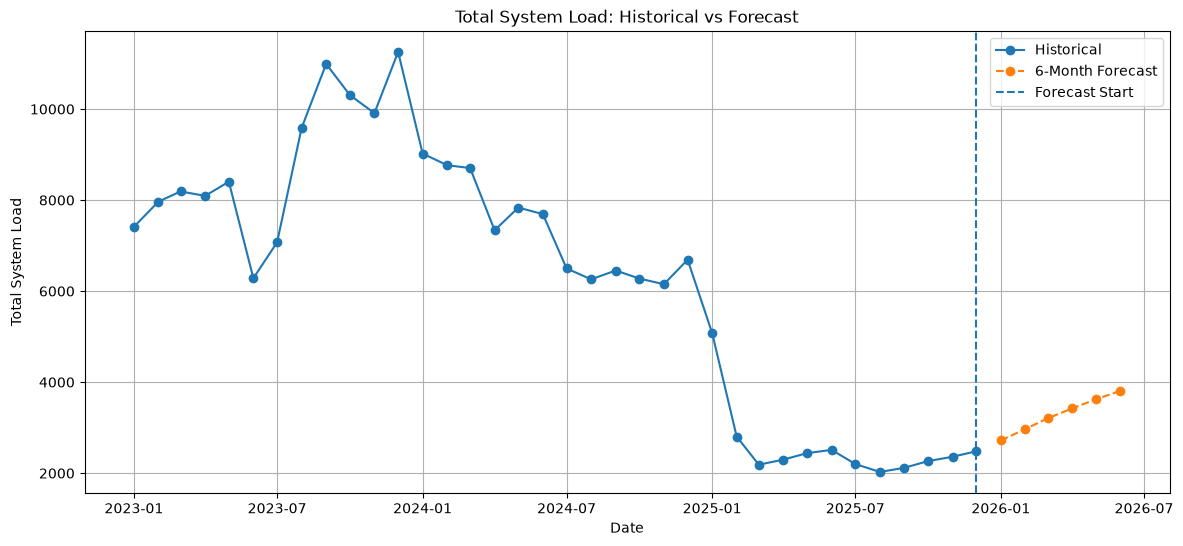

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_forecast.index,
    monthly_forecast.values,
    marker="o",
    label="Historical"
)

plt.plot(
    final_forecast_df["Date"],
    final_forecast_df["Forecast Total System Load"],
    marker="o",
    linestyle="--",
    label="6-Month Forecast"
)

plt.axvline(
    monthly_forecast.index[-1],
    linestyle="--",
    label="Forecast Start"
)

plt.title("Total System Load: Historical vs Forecast")
plt.xlabel("Date")
plt.ylabel("Total System Load")
plt.legend()
plt.grid(True)

plt.show()

In [36]:
import os

processed_path = "../data/processed"

print("===== FINAL PROJECT FILES =====")

for file in sorted(os.listdir(processed_path)):
    print(file)

===== FINAL PROJECT FILES =====
30_day_forecast.csv
6_month_forecast.csv
analytics_data.csv
cleaned_data.csv
final_forecast_summary.csv
final_kpi_dashboard.csv
kpi_summary.csv
monthly_dashboard_data.csv


In [37]:
data/processed/analytics_data.csv

NameError: name 'data' is not defined

In [38]:
data/processed/analytics_data.csv

NameError: name 'data' is not defined

In [39]:
import pandas as pd

df = pd.read_csv("../data/processed/analytics_data.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.head())

Rows: 720
Columns: 12
         Date  Children apprehended and placed in CBP custody*  \
0  2023-01-12                                               33   
1  2023-01-22                                               32   
2  2023-01-23                                               32   
3  2023-01-24                                               47   
4  2023-01-25                                               20   

   Children in CBP custody  Children transferred out of CBP custody  \
0                       53                                       34   
1                       49                                       39   
2                       50                                       39   
3                       42                                       47   
4                       22                                       41   

   Children in HHS Care  Children discharged from HHS Care  Total System Load  \
0                  6566                                436               

In [40]:
file_path = "../data/processed/analytics_data.csv"
print(file_path)

../data/processed/analytics_data.csv


In [41]:
import os

processed_path = "../data/processed"

print("===== PROCESSED FILES =====")

for file in sorted(os.listdir(processed_path)):
    print(file)

===== PROCESSED FILES =====
30_day_forecast.csv
6_month_forecast.csv
analytics_data.csv
cleaned_data.csv
final_forecast_summary.csv
final_kpi_dashboard.csv
kpi_summary.csv
monthly_dashboard_data.csv


In [42]:
required_files = [
    "analytics_data.csv",
    "cleaned_data.csv",
    "kpi_summary.csv",
    "6_month_forecast.csv",
    "monthly_dashboard_data.csv",
    "final_forecast_summary.csv",
    "final_kpi_dashboard.csv"
]

print("\n===== FILE CHECK =====")

for file in required_files:
    path = os.path.join(processed_path, file)
    print(file, "->", "OK" if os.path.exists(path) else "MISSING")


===== FILE CHECK =====
analytics_data.csv -> OK
cleaned_data.csv -> OK
kpi_summary.csv -> OK
6_month_forecast.csv -> OK
monthly_dashboard_data.csv -> OK
final_forecast_summary.csv -> OK
final_kpi_dashboard.csv -> OK
